In [64]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population, compute_total_population, compute_rur_urb_pop
from imagematerials.util import merge_dims, dataset_to_array


In [65]:
import warnings
from pathlib import Path

import xarray as xr
import numpy as np

from imagematerials.constants import IMAGE_REGIONS

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.materials import (
    compute_mat_intensities_commercial,
    compute_mat_intensities_residential,
)
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.concepts import create_building_graph
from imagematerials.concepts import create_region_graph

from imagematerials.buildings.preprocessing.circular_economy_measures import apply_circular_economy_commercial_floorspace


In [66]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [67]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


In [68]:


# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})



In [69]:
print(floorspace_commercial.pint.units)

meter ** 2 / person


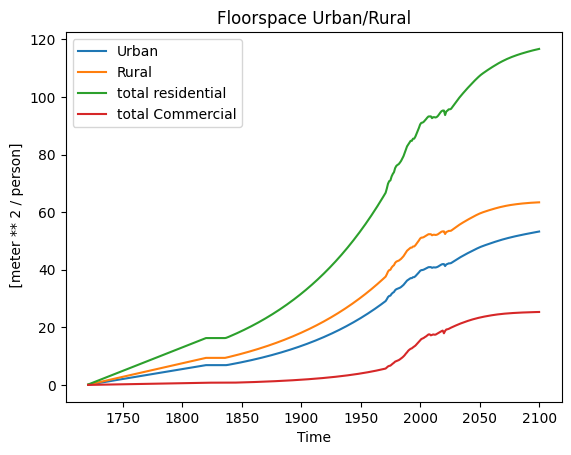

In [70]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sel(Area="Urban", Region = '11').plot(label="Urban")
floorspace_rururb.sel(Area="Rural", Region = '11').plot(label="Rural")
floorspace_rururb.sel(Region = '11').sum(["Area"]).plot(label="total residential")
floorspace_commercial.sel(Region = '11').sum(["Type"]).plot(label="total Commercial")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [71]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

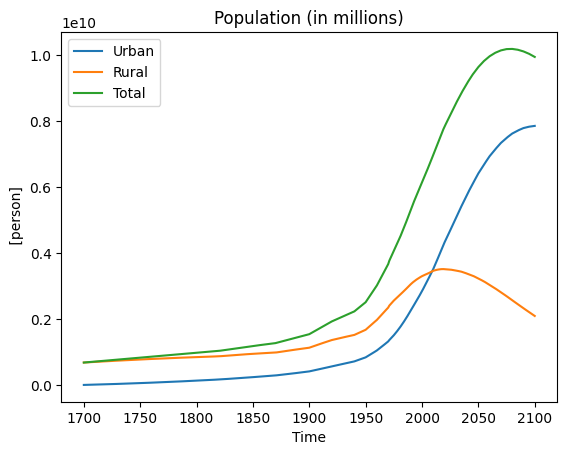

In [72]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [73]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
print('average_m2_capita:', average_m2_capita.pint.units)
housing_type = compute_housing_type(database_directory)

average_m2_capita: meter ** 2 / person


In [74]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, 
                                                     average_m2_capita, 
                                                     housing_type, 
                                                     floorspace_rururb, {"test":None})

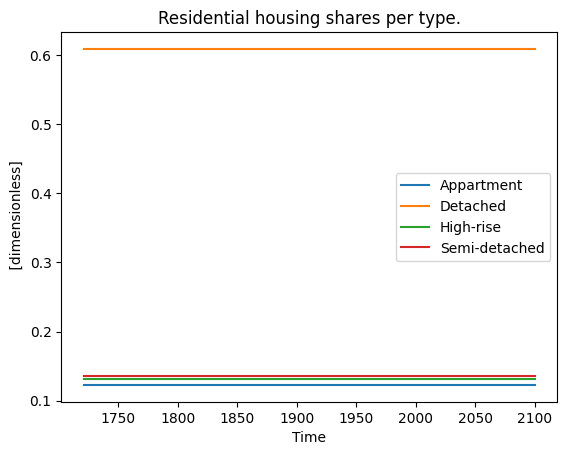

In [75]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

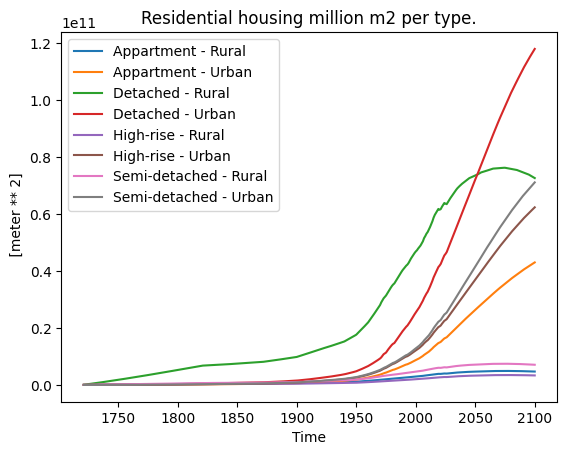

In [76]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [77]:
floorspace_commercial_total = floorspace_commercial * population.sel({"Area": "Total"})


In [78]:
circular_economy_config = {"test": None}

floorspace_commercial_total = floorspace_commercial_total.drop_vars("Area")
floorspace = xr.concat((floorspace_residential, floorspace_commercial_total), dim="Type")

# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values, circular_economy_config)

mat_intensities_comm = compute_mat_intensities_commercial(database_directory, circular_economy_config)
mat_intensities_res = compute_mat_intensities_residential(database_directory, circular_economy_config)
mat_intensities = xr.concat((mat_intensities_res, mat_intensities_comm), dim="Type")
knowledge_graph = create_building_graph()
mat_intensities = knowledge_graph.rebroadcast_xarray(
                        mat_intensities, floorspace.coords["Type"].values)

#TODO remove this quick fix
region_coords = np.sort(floorspace.coords["Region"].values.astype(int)).astype(str)



C:\Users\Arp00003\AppData\Local\Temp\ipykernel_2712\3194741200.py:14: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'material' ('material',) The recommendation is to set join explicitly for this case.
  mat_intensities = xr.concat((mat_intensities_res, mat_intensities_comm), dim="Type")


In [79]:
lifetimes.get("weibull")
knowledge_graph_region = create_region_graph()


In [80]:
lifetimes.get("weibull").coords


Coordinates:
  * Type        (Type) object 96B 'Office' 'Retail+' ... 'Semi-detached - Urban'
  * Time        (Time) int64 3kB 1721 1722 1723 1724 ... 2097 2098 2099 2100
  * ScipyParam  (ScipyParam) <U5 40B 'c' 'scale'
  * Region      (Region) <U2 208B '1' '2' '3' '4' '5' ... '23' '24' '25' '26'

In [ ]:
lifetime_new = lifetimes.copy()

for key, value in lifetime_new.items():
    lifetime_new[key] = knowledge_graph_region.rebroadcast_xarray(value, output_coords=IMAGE_REGIONS, dim="Region")

In [86]:
# Returns a single bool
same = lifetime_new["weibull"].identical(lifetimes.get("weibull"))
print('identical:', same)

identical: False


In [87]:
import numpy as np

def coords_equal(da1, da2):
    coords1 = da1.coords
    coords2 = da2.coords
    # same coordinate names?
    if set(coords1.keys()) != set(coords2.keys()):
        return False
    # compare each coordinate array
    for k in coords1.keys():
        if not np.array_equal(coords1[k].values, coords2[k].values):
            return False
    return True

print(coords_equal(lifetime_new["weibull"], lifetimes.get("weibull")))

False


In [83]:
floorspace

<xarray.DataArray (Time: 380, Region: 26, Type: 12)> Size: 948kB
<Quantity([[[1.94112122e+04 2.33979603e+03 3.18830904e+05 ... 5.42445245e+02
   1.48832914e+03 3.09978722e+04]
  [5.74358881e+04 9.96885836e+03 3.41163469e+06 ... 5.71295070e+03
   1.49032797e+04 3.22177936e+05]
  [4.66251279e+04 4.71459080e+03 7.65821911e+05 ... 1.28612800e+03
   3.52880185e+03 7.34954024e+04]
  ...
  [1.08914378e+04 2.83594781e+03 3.38412531e+05 ... 4.29927039e+02
   1.17960835e+03 2.45680528e+04]
  [2.27804062e+05 3.87528645e+03 2.30624915e+06 ... 4.11718961e+03
   1.12965010e+04 2.35275576e+05]
  [4.31981770e+04 8.58505148e+02 7.09533935e+05 ... 1.14725538e+03
   3.14777137e+03 6.55595677e+04]]

 [[3.88616329e+04 4.92197537e+03 6.38305809e+05 ... 1.08921586e+03
   2.98852597e+03 6.22429165e+04]
  [1.14997536e+05 2.09704071e+04 6.83073936e+06 ... 1.14714555e+04
   2.99253957e+04 6.46924868e+05]
  [9.34055275e+04 9.91757381e+03 1.53419417e+06 ... 2.58251139e+03
   7.08574180e+03 1.47576845e+05]
...
  [3.93461920e+06 4.39557941e+08 1.22254240e+08 ... 3.71073764e+08
   1.38698635e+08 4.60700022e+08]
  [6.64611922e+08 2.32241313e+09 6.72841683e+09 ... 5.23913238e+09
   1.73843094e+09 7.71136450e+09]
  [3.51434010e+08 1.96933753e+09 5.77233516e+09 ... 1.50959080e+09
   5.90800987e+08 3.83756666e+09]]

 [[5.54195850e+06 3.48177358e+08 9.10271660e+07 ... 3.60354022e+08
   1.36721319e+08 4.47856689e+08]
  [1.52524584e+07 1.62126981e+09 9.05980877e+08 ... 3.29281312e+09
   1.23879379e+09 4.08920373e+09]
  [2.36289008e+07 1.00163384e+09 3.88106817e+08 ... 1.00475394e+09
   3.34682068e+08 1.39054261e+09]
  ...
  [3.86633603e+06 4.39618463e+08 1.20132584e+08 ... 3.70871550e+08
   1.38777652e+08 4.60460027e+08]
  [6.61368251e+08 2.34391952e+09 6.69557846e+09 ... 5.33443712e+09
   1.76987606e+09 7.74881489e+09]
  [3.53440498e+08 2.00726362e+09 5.80529192e+09 ... 1.59642352e+09
   6.14592676e+08 3.90887473e+09]]], 'meter ** 2')>
Coordinates:
  * Region   (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * Time     (Time) int64 3kB 1721 1722 1723 1724 1725 ... 2097 2098 2099 2100
  * Type     (Type) <U21 1kB 'Appartment - Rural' ... 'Govt+'